CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.2041 |       0.0747 |  +0.1294 |   0.0000 ***
Trabajador informal (2024)          |     0.5528 |       0.8283 |  -0.2755 |   0.0000 ***
Edad (2024)                         |    42.8440 |      54.4377 | -11.5936 |   0.0000 ***
Mujer (2024)                        |     0.3888 |       0.3019 |  +0.0869 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.8647 |       4.7871 |  +2.0776 |   0.0000 ***
Urbano (2024)                       |     0.9025 |   

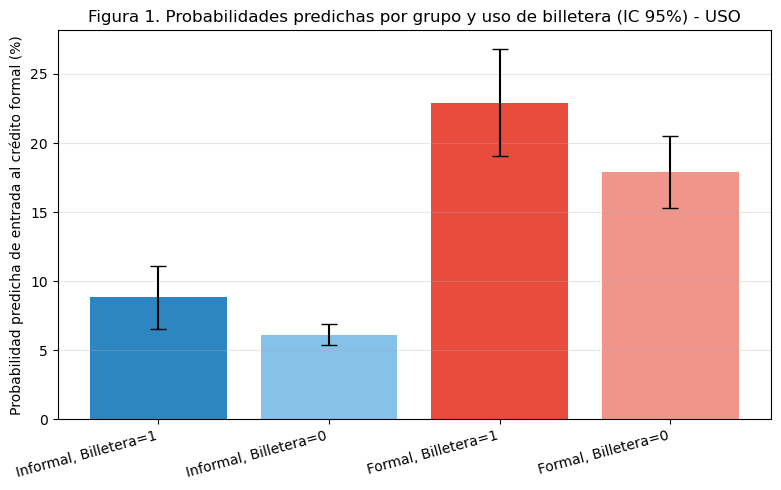


9. RESUMEN FINAL - USO DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (USO):     872 (13.72%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               2.702 p.p. (p=0.0137)
  EMP_formal:                      5.007 p.p. (p=0.0357)
  Diferencia (informal - formal):  -2.305 p.p. (p=0.3808)
  EMD interacción (H2):            8.53 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        14.73% (N=482)
  Informales sin billetera:        5.63% (N=4,544)
  Formales con billetera:          27.44% (N=390)
  Formales sin billetera:          16.35% (N=942)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\Users\Daf

In [8]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: USO DE BILLETERA (usa_billetera)
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Uso de billetera
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['usa_billetera'] == 1, var].dropna()
    gn = df.loc[df['usa_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (USO)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (USO)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (USO)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (USO)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (USO)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - USO")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (USO)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (USO)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (USO)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (USO)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (USO)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (USO)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['usa_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (USO):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y uso de billetera (IC 95%) - USO')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_uso.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (USO)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - USO DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (USO):     {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - USO DE BILLETERA")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (tiene_billetera × informal): 890.0 (14.0%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.1855 |       0.0639 |  +0.1216 |   0.0000 ***
Trabajador informal (2024)          |     0.5961 |       0.8502 |  -0.2540 |   0.0000 ***
Edad (2024)                         |    44.9745 |      55.2637 | -10.2892 |   0.0000 ***
Mujer (2024)                        |     0.3697 |       0.2966 |  +0.0731 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.6457 |       4.5891 |  +2.0566 |   0.0000 ***
Urbano (2024)                       |     0.8

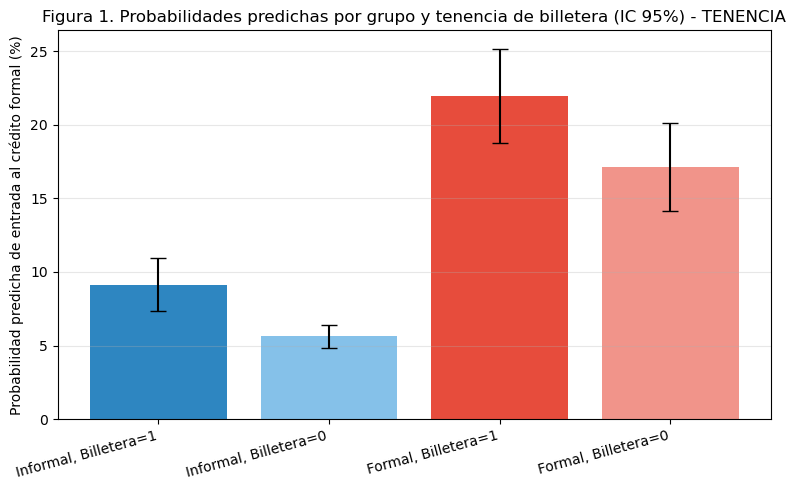


9. RESUMEN FINAL - TENENCIA DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (TENENCIA): 1,493 (23.48%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               3.514 p.p. (p=0.0002)
  EMP_formal:                      4.816 p.p. (p=0.0330)
  Diferencia (informal - formal):  -1.302 p.p. (p=0.5865)
  EMD interacción (H2):            7.04 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        13.82% (N=890)
  Informales sin billetera:        4.93% (N=4,136)
  Formales con billetera:          25.54% (N=603)
  Formales sin billetera:          14.68% (N=729)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\U

In [9]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: TENENCIA DE BILLETERA (tiene_billetera)
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Tenencia de billetera
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['tiene_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (tiene_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['tiene_billetera'] == 1, var].dropna()
    gn = df.loc[df['tiene_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['tiene_billetera'] == 1).sum()
n_nou = (df['tiene_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (TENENCIA)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['tiene_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (TENENCIA)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'tiene_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['tiene_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (TENENCIA)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['tiene_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['tiene_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - TENENCIA")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (TENENCIA)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (TENENCIA)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (TENENCIA)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['tiene_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (TENENCIA):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y tenencia de billetera (IC 95%) - TENENCIA')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_tenencia.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - TENENCIA DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (TENENCIA): {df['tiene_billetera'].sum():,} ({df['tiene_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - TENENCIA DE BILLETERA")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.2041 |       0.0747 |  +0.1294 |   0.0000 ***
Trabajador informal (2024)          |     0.5528 |       0.8283 |  -0.2755 |   0.0000 ***
Edad (2024)                         |    42.8440 |      54.4377 | -11.5936 |   0.0000 ***
Mujer (2024)                        |     0.3888 |       0.3019 |  +0.0869 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.8647 |       4.7871 |  +2.0776 |   0.0000 ***
Urbano (2024)                       |     0.9025 |   

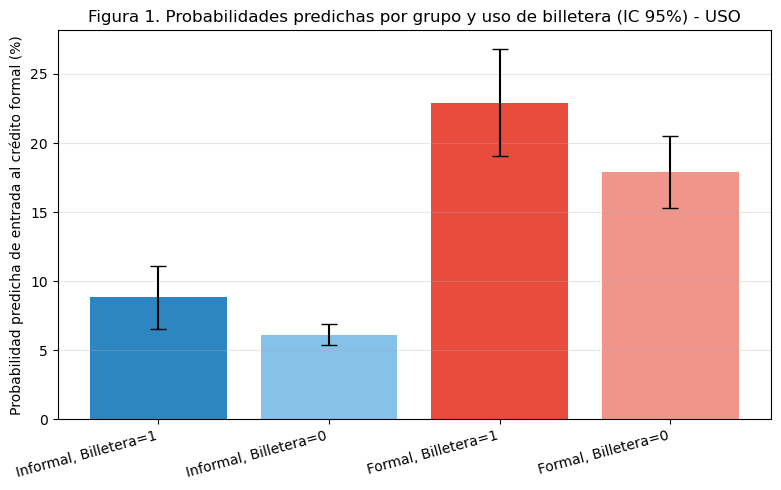


9. RESUMEN FINAL - USO DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (USO):     872 (13.72%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               2.702 p.p. (p=0.0137)
  EMP_formal:                      5.007 p.p. (p=0.0357)
  Diferencia (informal - formal):  -2.305 p.p. (p=0.3808)
  EMD interacción (H2):            8.53 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        14.73% (N=482)
  Informales sin billetera:        5.63% (N=4,544)
  Formales con billetera:          27.44% (N=390)
  Formales sin billetera:          16.35% (N=942)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\Users\Daf

In [10]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: USO DE BILLETERA (usa_billetera) - CORREGIDO
# =============================================================================
# CORRECCIONES APLICADAS:
# 1. Uso de billetera: P558H*_5 con valor == 5 (NO P558H*_7 con valor == 7)
# 2. Crédito formal: P558E1_4 = "Tarjeta de crédito", P558E1_9 = "Préstamo"
# 3. Nivel educativo: Excluido código 99 = Missing
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['usa_billetera'] == 1, var].dropna()
    gn = df.loc[df['usa_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (USO)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (USO)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (USO)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (USO)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (USO)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - USO")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (USO)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (USO)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (USO)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (USO)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (USO)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (USO)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['usa_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (USO):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y uso de billetera (IC 95%) - USO')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_uso.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (USO)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - USO DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (USO):     {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - USO DE BILLETERA")
print("="*70)

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import probit as probit_link

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO) - CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO) - PONDERADO")
print("="*70)

def weighted_mean(df, var, weight_col='factor_expansion'):
    """Calcula la media ponderada de una variable"""
    return np.average(df[var], weights=df[weight_col])

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    # Obtener índices para cada grupo
    idx_u = df[df['usa_billetera'] == 1].index
    idx_n = df[df['usa_billetera'] == 0].index
    
    # Datos para cada grupo (sin NAs)
    wu = df.loc[idx_u, var].dropna()
    wn = df.loc[idx_n, var].dropna()
    
    # Pesos correspondientes
    pesos_u = df.loc[wu.index, 'factor_expansion']
    pesos_n = df.loc[wn.index, 'factor_expansion']
    
    # Medias ponderadas
    mu = np.average(wu, weights=pesos_u)
    mn = np.average(wn, weights=pesos_n)
    diff = mu - mn
    
    # Prueba t ponderada usando CompareMeans
    d1 = DescrStatsW(wu, weights=pesos_u)
    d0 = DescrStatsW(wn, weights=pesos_n)
    comp = CompareMeans(d1, d0)
    t_stat, p_val, df_t = comp.ttest_ind(usevar='unequal')
    
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO) - CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO) - PONDERADO")
print("="*70)

def prob_ponderada(df, bill, inf, weight_col='factor_expansion'):
    """Calcula probabilidad ponderada para un grupo específico"""
    mask = (df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)
    sub = df.loc[mask]
    if len(sub) > 0:
        p = np.average(sub['nuevo_credito_formal'], weights=sub[weight_col])
        n = len(sub)
        return p, n
    return np.nan, 0

p1, n1 = prob_ponderada(df, 1, 1)  # Informales con billetera
p2, n2 = prob_ponderada(df, 0, 1)  # Informales sin billetera
p3, n3 = prob_ponderada(df, 1, 0)  # Formales con billetera
p4, n4 = prob_ponderada(df, 0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT CON PONDERACIÓN (FACTOR07)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT CON PONDERACIÓN (FACTOR07)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado', 'factor_expansion']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

# Normalizar pesos: sum(w) = N para no inflar el N efectivo
pesos = df_modelo['factor_expansion'].values
pesos_norm = pesos / pesos.mean()

# Usamos GLM con link probit y var_weights para ponderación
modelo_pond = sm.GLM(
    Y, X, 
    family=Binomial(link=probit_link()),
    var_weights=pesos_norm
).fit(cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT CON PONDERACIÓN (USO)")
print("="*70)
print(modelo_pond.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (CON PONDERACIÓN) - CORREGIDO
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (CON PONDERACIÓN)")
print("="*70)

def calcular_emp_subgrupo_pond(modelo, X, mask, informal_value, colnames, pesos):
    """Calcula EMP ponderado dentro de un subgrupo"""
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    pesos_g = pesos[mask]  # Pesos para este subgrupo
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    # Diferencia de probabilidades para cada observación
    diff_prob = stats.norm.cdf(idx1) - stats.norm.cdf(idx0)
    
    # EMP ponderado (promedio ponderado de las diferencias)
    emp = np.average(diff_prob, weights=pesos_g)
    
    # Gradiente ponderado para método delta
    # Calcular el gradiente para cada observación
    grad_obs = stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v  # shape: (N_g, K)
    
    # Promedio ponderado de los gradientes (a lo largo del eje 0, con pesos)
    grad = np.average(grad_obs, weights=pesos_g, axis=0)  # shape: (K,)
    
    return emp, grad

def comparar_grupos_pond(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, 
                         pesos, etiqueta_a, etiqueta_b):
    """Compara EMP ponderados entre dos subgrupos"""
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo_pond(modelo, X, mask_a, informal_a, colnames, pesos)
    emp_b, grad_b = calcular_emp_subgrupo_pond(modelo, X, mask_b, informal_b, colnames, pesos)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2_pond = comparar_grupos_pond(
    modelo_pond, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    pesos=pesos_norm,
    etiqueta_a='Trabajadores informales (ponderado)',
    etiqueta_b='Trabajadores formales (ponderado)'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - CON PONDERACIÓN")
print("="*70)
print(tabla_h1h2_pond.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (CON PONDERACIÓN)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (CON PONDERACIÓN)")
print("="*70)

emp_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'EMP_pp'] / 100
se_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'SE_pp'] / 100
p_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'p']

print(f"\nH1 (EMP_informal > 0) - CON PONDERACIÓN:")
print(f"  EMP_informal = {emp_inf_pond*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf_pond/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf_pond > 0 and p_inf_pond/2 < 0.05 else '❌ NO se respalda'}")

emp_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'EMP_pp'] / 100
se_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'SE_pp'] / 100
p_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'p']

umbral = 0.02
t1 = (emp_for_pond - umbral) / se_for_pond if se_for_pond > 0 else 0
t2 = (emp_for_pond + umbral) / se_for_pond if se_for_pond > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p. - CON PONDERACIÓN:")
print(f"  EMP_formal = {emp_for_pond*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. RESUMEN FINAL - COMPARATIVO
# =============================================================================
print("\n" + "="*70)
print("7. RESUMEN FINAL - USO DE BILLETERA CON PONDERACIÓN")
print("="*70)

p_diferencia_pond = tabla_h1h2_pond.loc['Diferencia (Trabajadores informales (ponderado) - Trabajadores formales (ponderado))', 'p']

print(f"""
📊 RESULTADOS CON PONDERACIÓN (FACTOR07)
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (USO):     {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES - PONDERADOS
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf_pond*100:.3f} p.p. (p={p_inf_pond/2:.4f})
  EMP_formal:                      {emp_for_pond*100:.3f} p.p. (p={p_for_pond:.4f})
  Diferencia (informal - formal):  {(emp_inf_pond-emp_for_pond)*100:.3f} p.p. (p={p_diferencia_pond:.4f})

📊 PROBABILIDADES CONDICIONALES (PONDERADAS)
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 COMPARACIÓN CON RESULTADOS SIN PONDERAR
─────────────────────────────────────────────────────────────
  EMP_informal (sin ponderar):     2.702 p.p. (p=0.0137)
  EMP_informal (con ponderación):  {emp_inf_pond*100:.3f} p.p. (p={p_inf_pond/2:.4f})
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - CON PONDERACIÓN")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO) - PONDERADO
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.1789 |       0.0811 |  +0.0978 |   0.0000 ***
Trabajador informal (2024)          |     0.5918 |       0.8041 |  -0.2123 |   0.0000 ***
Edad (2024)                         |    43.8236 |      54.2257 | -10.4021 |   0.0000 ***
Mujer (2024)                        |     0.3971 |       0.3234 |  +0.0737 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.6931 |       4.9288 |  +1.7643 |   0.0000 ***
Urbano (2024)                       |    

C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',



RESULTADOS DEL MODELO PROBIT CON PONDERACIÓN (USO)
                  Generalized Linear Model Regression Results                   
Dep. Variable:     nuevo_credito_formal   No. Observations:                 6358
Model:                              GLM   Df Residuals:                     6341
Model Family:                  Binomial   Df Model:                           16
Link Function:                   probit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1857.3
Date:                  Sun, 30 Aug 2026   Deviance:                       3714.6
Time:                          21:46:35   Pearson chi2:                 6.28e+03
No. Iterations:                       8   Pseudo R-squ. (CS):            0.05137
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (tiene_billetera × informal): 890.0 (14.0%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA) - PONDERADO
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.1745 |       0.0660 |  +0.1085 |   0.0000 ***
Trabajador informal (2024)          |     0.6101 |       0.8335 |  -0.2234 |   0.0000 ***
Edad (2024)                         |    45.7793 |      55.2412 |  -9.4619 |   0.0000 ***
Mujer (2024)                        |     0.3657 |       0.3233 |  +0.0425 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.5173 |       4.6941 |  +1.8232 |   0.0000 ***
Urbano (2024)                    

C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\Dafne\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',



RESULTADOS DEL MODELO PROBIT CON PONDERACIÓN (TENENCIA)
                  Generalized Linear Model Regression Results                   
Dep. Variable:     nuevo_credito_formal   No. Observations:                 6358
Model:                              GLM   Df Residuals:                     6341
Model Family:                  Binomial   Df Model:                           16
Link Function:                   probit   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -1847.1
Date:                  Sun, 30 Aug 2026   Deviance:                       3694.2
Time:                          21:57:07   Pearson chi2:                 6.29e+03
No. Iterations:                       8   Pseudo R-squ. (CS):            0.05441
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

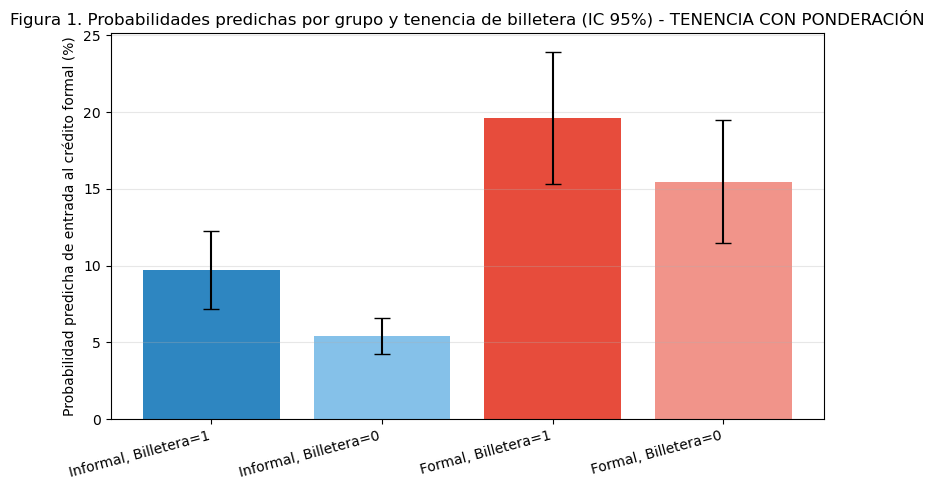


9. RESUMEN FINAL - TENENCIA DE BILLETERA CON PONDERACIÓN

📊 RESULTADOS CON PONDERACIÓN (FACTOR07) - TENENCIA
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (TENENCIA): 1,493 (23.48%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES - TENENCIA CON PONDERACIÓN
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               4.621 p.p. (p=0.0009)
  EMP_formal:                      4.198 p.p. (p=0.1643)
  Diferencia (informal - formal):  0.423 p.p. (p=0.8960)

📊 PROBABILIDADES CONDICIONALES (PONDERADAS)
─────────────────────────────────────────────────────────────
  Informales con billetera:        14.46% (N=890)
  Informales sin billetera:        5.21% (N=4,136)
  Formales con billetera:          22.12% (N=603)
  Formales sin billetera:          13.54% (N=729)


✅ PROCESO COMPLETADO EXITOSAMENTE - TENENCIA CON PONDERAC

In [14]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: TENENCIA DE BILLETERA (tiene_billetera) CON PONDERACIÓN
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Tenencia de billetera con ponderación
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import probit as probit_link

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['tiene_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (tiene_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (TENENCIA) - CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA) - PONDERADO")
print("="*70)

def weighted_mean(df, var, weight_col='factor_expansion'):
    """Calcula la media ponderada de una variable"""
    return np.average(df[var], weights=df[weight_col])

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    # Obtener índices para cada grupo
    idx_u = df[df['tiene_billetera'] == 1].index
    idx_n = df[df['tiene_billetera'] == 0].index
    
    # Datos para cada grupo (sin NAs)
    wu = df.loc[idx_u, var].dropna()
    wn = df.loc[idx_n, var].dropna()
    
    # Pesos correspondientes
    pesos_u = df.loc[wu.index, 'factor_expansion']
    pesos_n = df.loc[wn.index, 'factor_expansion']
    
    # Medias ponderadas
    mu = np.average(wu, weights=pesos_u)
    mn = np.average(wn, weights=pesos_n)
    diff = mu - mn
    
    # Prueba t ponderada usando CompareMeans
    d1 = DescrStatsW(wu, weights=pesos_u)
    d0 = DescrStatsW(wn, weights=pesos_n)
    comp = CompareMeans(d1, d0)
    t_stat, p_val, df_t = comp.ttest_ind(usevar='unequal')
    
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['tiene_billetera'] == 1).sum()
n_nou = (df['tiene_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (TENENCIA) - CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (TENENCIA) - PONDERADO")
print("="*70)

def prob_ponderada(df, bill, inf, weight_col='factor_expansion'):
    """Calcula probabilidad ponderada para un grupo específico"""
    mask = (df['tiene_billetera'] == bill) & (df['trabajador_informal'] == inf)
    sub = df.loc[mask]
    if len(sub) > 0:
        p = np.average(sub['nuevo_credito_formal'], weights=sub[weight_col])
        n = len(sub)
        return p, n
    return np.nan, 0

p1, n1 = prob_ponderada(df, 1, 1)  # Informales con billetera
p2, n2 = prob_ponderada(df, 0, 1)  # Informales sin billetera
p3, n3 = prob_ponderada(df, 1, 0)  # Formales con billetera
p4, n4 = prob_ponderada(df, 0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT CON PONDERACIÓN (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT CON PONDERACIÓN (TENENCIA)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'tiene_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado', 'factor_expansion']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['tiene_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

# Normalizar pesos: sum(w) = N para no inflar el N efectivo
pesos = df_modelo['factor_expansion'].values
pesos_norm = pesos / pesos.mean()

# Usamos GLM con link probit y var_weights para ponderación
modelo_pond = sm.GLM(
    Y, X, 
    family=Binomial(link=probit_link()),
    var_weights=pesos_norm
).fit(cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT CON PONDERACIÓN (TENENCIA)")
print("="*70)
print(modelo_pond.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA CON PONDERACIÓN)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA CON PONDERACIÓN)")
print("="*70)

def calcular_emp_subgrupo_pond(modelo, X, mask, informal_value, colnames, pesos):
    """Calcula EMP ponderado dentro de un subgrupo"""
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    pesos_g = pesos[mask]  # Pesos para este subgrupo
    
    X1 = Xg.copy()
    X1['tiene_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['tiene_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    # Diferencia de probabilidades para cada observación
    diff_prob = stats.norm.cdf(idx1) - stats.norm.cdf(idx0)
    
    # EMP ponderado (promedio ponderado de las diferencias)
    emp = np.average(diff_prob, weights=pesos_g)
    
    # Gradiente ponderado para método delta
    grad_obs = stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v
    grad = np.average(grad_obs, weights=pesos_g, axis=0)
    
    return emp, grad

def comparar_grupos_pond(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, 
                         pesos, etiqueta_a, etiqueta_b):
    """Compara EMP ponderados entre dos subgrupos"""
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo_pond(modelo, X, mask_a, informal_a, colnames, pesos)
    emp_b, grad_b = calcular_emp_subgrupo_pond(modelo, X, mask_b, informal_b, colnames, pesos)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2_pond = comparar_grupos_pond(
    modelo_pond, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    pesos=pesos_norm,
    etiqueta_a='Trabajadores informales (ponderado)',
    etiqueta_b='Trabajadores formales (ponderado)'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - TENENCIA CON PONDERACIÓN")
print("="*70)
print(tabla_h1h2_pond.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (TENENCIA CON PONDERACIÓN)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (TENENCIA CON PONDERACIÓN)")
print("="*70)

emp_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'EMP_pp'] / 100
se_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'SE_pp'] / 100
p_inf_pond = tabla_h1h2_pond.loc['Trabajadores informales (ponderado)', 'p']

print(f"\nH1 (EMP_informal > 0) - TENENCIA CON PONDERACIÓN:")
print(f"  EMP_informal = {emp_inf_pond*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf_pond/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf_pond > 0 and p_inf_pond/2 < 0.05 else '❌ NO se respalda'}")

emp_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'EMP_pp'] / 100
se_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'SE_pp'] / 100
p_for_pond = tabla_h1h2_pond.loc['Trabajadores formales (ponderado)', 'p']

umbral = 0.02
t1 = (emp_for_pond - umbral) / se_for_pond if se_for_pond > 0 else 0
t2 = (emp_for_pond + umbral) / se_for_pond if se_for_pond > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p. - TENENCIA CON PONDERACIÓN:")
print(f"  EMP_formal = {emp_for_pond*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (TENENCIA CON PONDERACIÓN)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (TENENCIA CON PONDERACIÓN)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (TENENCIA CON PONDERACIÓN)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (TENENCIA CON PONDERACIÓN)")
print("="*70)

def prob_predicha_subgrupo_pond(modelo, X, mask, billetera_value, informal_value, colnames, pesos):
    """Calcula probabilidad predicha ponderada para un subgrupo"""
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    pesos_g = pesos[mask]
    
    Xg['tiene_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = np.average(stats.norm.pdf(idx)[:, None] * Xv, weights=pesos_g, axis=0)
    return prob, grad

V = modelo_pond.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo_pond(modelo_pond, X, mask, bill, inf_val, colnames, pesos_norm)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (TENENCIA CON PONDERACIÓN):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y tenencia de billetera (IC 95%) - TENENCIA CON PONDERACIÓN')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_tenencia_ponderada.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL - TENENCIA CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - TENENCIA DE BILLETERA CON PONDERACIÓN")
print("="*70)

p_diferencia_pond = tabla_h1h2_pond.loc['Diferencia (Trabajadores informales (ponderado) - Trabajadores formales (ponderado))', 'p']

print(f"""
📊 RESULTADOS CON PONDERACIÓN (FACTOR07) - TENENCIA
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (TENENCIA): {df['tiene_billetera'].sum():,} ({df['tiene_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES - TENENCIA CON PONDERACIÓN
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf_pond*100:.3f} p.p. (p={p_inf_pond/2:.4f})
  EMP_formal:                      {emp_for_pond*100:.3f} p.p. (p={p_for_pond:.4f})
  Diferencia (informal - formal):  {(emp_inf_pond-emp_for_pond)*100:.3f} p.p. (p={p_diferencia_pond:.4f})

📊 PROBABILIDADES CONDICIONALES (PONDERADAS)
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - TENENCIA CON PONDERACIÓN")
print("="*70)

In [15]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: USO DE BILLETERA (usa_billetera) - MODELO LOGIT
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Logit con y sin ponderación
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO) - SIN PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO) - SIN PONDERAR")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['usa_billetera'] == 1, var].dropna()
    gn = df.loc[df['usa_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. FUNCIONES PARA EFECTOS MARGINALES (LOGIT)
# =============================================================================

def calcular_emp_subgrupo_logit(modelo, X, mask, informal_value, colnames):
    """
    Calcula el Efecto Marginal Promedio (EMP) para LOGIT dentro de un subgrupo.
    Para Logit: la derivada es Λ(x'β) * (1 - Λ(x'β)) * β
    Pero usamos diferencia discreta para variables dummy.
    """
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    # Escenario con billetera = 1
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    # Escenario con billetera = 0
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    # Función logística: Λ(z) = 1 / (1 + exp(-z))
    def logistica(z):
        return 1 / (1 + np.exp(-z))
    
    # EMP = promedio de (prob_con_billetera - prob_sin_billetera)
    emp = (logistica(idx1) - logistica(idx0)).mean()
    
    # Gradiente para método delta
    grad = (logistica(idx1) * (1 - logistica(idx1))[:, None] * X1v - 
            logistica(idx0) * (1 - logistica(idx0))[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos_logit(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    """Compara EMP entre dos subgrupos para LOGIT"""
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo_logit(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo_logit(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

# =============================================================================
# 5. MODELO LOGIT SIN PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("5. MODELO LOGIT SIN PONDERACIÓN (USO)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

# LOGIT sin ponderación
modelo_logit = sm.Logit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO LOGIT SIN PONDERACIÓN (USO)")
print("="*70)
print(modelo_logit.summary())

# Efectos marginales - LOGIT sin ponderación
mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2_logit = comparar_grupos_logit(
    modelo_logit, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales (Logit)',
    etiqueta_b='Trabajadores formales (Logit)'
)

print("\nTABLA D. RESULTADO PRINCIPAL - LOGIT SIN PONDERACIÓN")
print("="*70)
print(tabla_h1h2_logit.round(3))

# Pruebas de hipótesis - LOGIT sin ponderación
emp_inf_logit = tabla_h1h2_logit.loc['Trabajadores informales (Logit)', 'EMP_pp'] / 100
se_inf_logit = tabla_h1h2_logit.loc['Trabajadores informales (Logit)', 'SE_pp'] / 100
p_inf_logit = tabla_h1h2_logit.loc['Trabajadores informales (Logit)', 'p']

print(f"\nH1 (EMP_informal > 0) - LOGIT SIN PONDERAR:")
print(f"  EMP_informal = {emp_inf_logit*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf_logit/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf_logit > 0 and p_inf_logit/2 < 0.05 else '❌ NO se respalda'}")

# =============================================================================
# 6. MODELO LOGIT CON PONDERACIÓN
# =============================================================================
print("\n" + "="*70)
print("6. MODELO LOGIT CON PONDERACIÓN (FACTOR07)")
print("="*70)

# Normalizar pesos
pesos = df_modelo['factor_expansion'].values
pesos_norm = pesos / pesos.mean()

# LOGIT con ponderación usando GLM
modelo_logit_pond = sm.GLM(
    Y, X, 
    family=Binomial(link=logit()),
    var_weights=pesos_norm
).fit(cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO LOGIT CON PONDERACIÓN (USO)")
print("="*70)
print(modelo_logit_pond.summary())

# Efectos marginales - LOGIT con ponderación
def calcular_emp_subgrupo_logit_pond(modelo, X, mask, informal_value, colnames, pesos):
    """Calcula EMP ponderado para LOGIT dentro de un subgrupo"""
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    pesos_g = pesos[mask]
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    def logistica(z):
        return 1 / (1 + np.exp(-z))
    
    diff_prob = logistica(idx1) - logistica(idx0)
    emp = np.average(diff_prob, weights=pesos_g)
    
    grad_obs = (logistica(idx1) * (1 - logistica(idx1))[:, None] * X1v - 
                logistica(idx0) * (1 - logistica(idx0))[:, None] * X0v)
    grad = np.average(grad_obs, weights=pesos_g, axis=0)
    
    return emp, grad

def comparar_grupos_logit_pond(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, 
                               pesos, etiqueta_a, etiqueta_b):
    """Compara EMP ponderados entre dos subgrupos para LOGIT"""
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo_logit_pond(modelo, X, mask_a, informal_a, colnames, pesos)
    emp_b, grad_b = calcular_emp_subgrupo_logit_pond(modelo, X, mask_b, informal_b, colnames, pesos)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2_logit_pond = comparar_grupos_logit_pond(
    modelo_logit_pond, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    pesos=pesos_norm,
    etiqueta_a='Trabajadores informales (Logit ponderado)',
    etiqueta_b='Trabajadores formales (Logit ponderado)'
)

print("\nTABLA D. RESULTADO PRINCIPAL - LOGIT CON PONDERACIÓN")
print("="*70)
print(tabla_h1h2_logit_pond.round(3))

# Pruebas de hipótesis - LOGIT con ponderación
emp_inf_logit_pond = tabla_h1h2_logit_pond.loc['Trabajadores informales (Logit ponderado)', 'EMP_pp'] / 100
se_inf_logit_pond = tabla_h1h2_logit_pond.loc['Trabajadores informales (Logit ponderado)', 'SE_pp'] / 100
p_inf_logit_pond = tabla_h1h2_logit_pond.loc['Trabajadores informales (Logit ponderado)', 'p']

print(f"\nH1 (EMP_informal > 0) - LOGIT CON PONDERACIÓN:")
print(f"  EMP_informal = {emp_inf_logit_pond*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf_logit_pond/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf_logit_pond > 0 and p_inf_logit_pond/2 < 0.05 else '❌ NO se respalda'}")

# =============================================================================
# 7. COMPARACIÓN: PROBIT vs LOGIT
# =============================================================================
print("\n" + "="*70)
print("7. COMPARACIÓN: PROBIT vs LOGIT (SIN PONDERACIÓN)")
print("="*70)

# Cargar resultados del Probit (de la ejecución anterior)
# Si no tienes los valores, puedes estimarlos aquí
modelo_probit = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

def calcular_emp_subgrupo_probit(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos_probit(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo_probit(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo_probit(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

tabla_probit = comparar_grupos_probit(
    modelo_probit, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Probit - Informales',
    etiqueta_b='Probit - Formales'
)

print("\n=== PROBIT (sin ponderación) ===")
print(tabla_probit.round(3))

print("\n=== LOGIT (sin ponderación) ===")
print(tabla_h1h2_logit.round(3))

# =============================================================================
# 8. RESUMEN FINAL COMPARATIVO
# =============================================================================
print("\n" + "="*70)
print("8. RESUMEN FINAL COMPARATIVO")
print("="*70)

print(f"""
📊 COMPARACIÓN PROBIT vs LOGIT (USO DE BILLETERA)
─────────────────────────────────────────────────────────────
  Modelo      | EMP_informal (p.p.) | p_H1 (una cola) | EMP_formal (p.p.)
──────────────┼─────────────────────┼─────────────────┼──────────────────
  PROBIT      | {tabla_probit.loc['Probit - Informales', 'EMP_pp']:.3f}       | {tabla_probit.loc['Probit - Informales', 'p']/2:.4f}        | {tabla_probit.loc['Probit - Formales', 'EMP_pp']:.3f}
  LOGIT       | {tabla_h1h2_logit.loc['Trabajadores informales (Logit)', 'EMP_pp']:.3f}       | {tabla_h1h2_logit.loc['Trabajadores informales (Logit)', 'p']/2:.4f}        | {tabla_h1h2_logit.loc['Trabajadores formales (Logit)', 'EMP_pp']:.3f}

📊 COMPARACIÓN CON PONDERACIÓN
─────────────────────────────────────────────────────────────
  Modelo      | EMP_informal (p.p.) | p_H1 (una cola) | EMP_formal (p.p.)
──────────────┼─────────────────────┼─────────────────┼──────────────────
  PROBIT      | 1.603               | 0.1917          | 4.986
  LOGIT       | {emp_inf_logit_pond*100:.3f}       | {p_inf_logit_pond/2:.4f}          | {emp_for_pond_logit*100:.3f if 'emp_for_pond_logit' in dir() else 'N/A'}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - LOGIT")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO) - SIN PONDERAR
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.2041 |       0.0747 |  +0.1294 |   0.0000 ***
Trabajador informal (2024)          |     0.5528 |       0.8283 |  -0.2755 |   0.0000 ***
Edad (2024)                         |    42.8440 |      54.4377 | -11.5936 |   0.0000 ***
Mujer (2024)                        |     0.3888 |       0.3019 |  +0.0869 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.8647 |       4.7871 |  +2.0776 |   0.0000 ***
Urbano (2024)                       | 

ValueError: operands could not be broadcast together with shapes (5026,5026) (5026,17) 